In [1]:
# ── Setup ──────────────────────────────────────────────────────
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

os.chdir(r"C:\Users\PREM\OneDrive\Desktop\Bluestock_MF_Capstone")

PROC = Path("data/processed")
RAW  = Path("data/raw")

print("Setup complete!")

Setup complete!


In [2]:
# ── Load files ─────────────────────────────────────────────────
nav_history  = pd.read_csv(PROC / "clean_nav.csv",         parse_dates=["date"])
transactions = pd.read_csv(PROC / "clean_transactions.csv", parse_dates=["transaction_date"])
fund_master  = pd.read_csv(RAW  / "01_fund_master.csv")
scorecard    = pd.read_csv(PROC / "fund_scorecard.csv")

nav_history["daily_return"] = (
    nav_history.groupby("amfi_code")["nav"].pct_change()
)

print("Files loaded!")

Files loaded!


In [3]:
var_results = []

for code, grp in nav_history.groupby("amfi_code"):
    rets = grp["daily_return"].dropna()
    if len(rets) < 50:
        continue

    var95  = np.percentile(rets, 5)
    cvar95 = rets[rets <= var95].mean()

    name = fund_master[fund_master["amfi_code"] == code]["scheme_name"].values
    var_results.append({
        "amfi_code"  : code,
        "scheme_name": name[0] if len(name) > 0 else str(code),
        "var_95_pct" : round(var95  * 100, 3),
        "cvar_95_pct": round(cvar95 * 100, 3)
    })

var_df = pd.DataFrame(var_results).sort_values("var_95_pct")
var_df.to_csv(PROC / "var_cvar.csv", index=False)
print("VaR and CVaR computed!")
var_df.head(10)

VaR and CVaR computed!


,amfi_code,scheme_name,var_95_pct,cvar_95_pct
22,119599,SBI Small Cap Fund - Direct Plan - Growth,-2.686,-3.238
17,119095,Axis Small Cap Fund - Regular - Growth,-2.619,-3.167
4,101207,ABSL Small Cap Fund - Regular - Growth,-2.602,-3.246
11,118634,Nippon India Small Cap Fund - Regular - Growth,-2.544,-3.230
21,119598,SBI Small Cap Fund - Regular Plan - Growth,-2.451,-3.060
39,149324,DSP Small Cap Fund - Regular - Growth,-2.348,-3.104
7,102886,UTI Mid Cap Fund - Regular - Growth,-1.922,-2.325
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,-1.903,-2.346
25,120505,ICICI Pru Midcap Fund - Regular - Growth,-1.889,-2.434
16,119094,Axis Midcap Fund - Regular - Growth,-1.848,-2.426


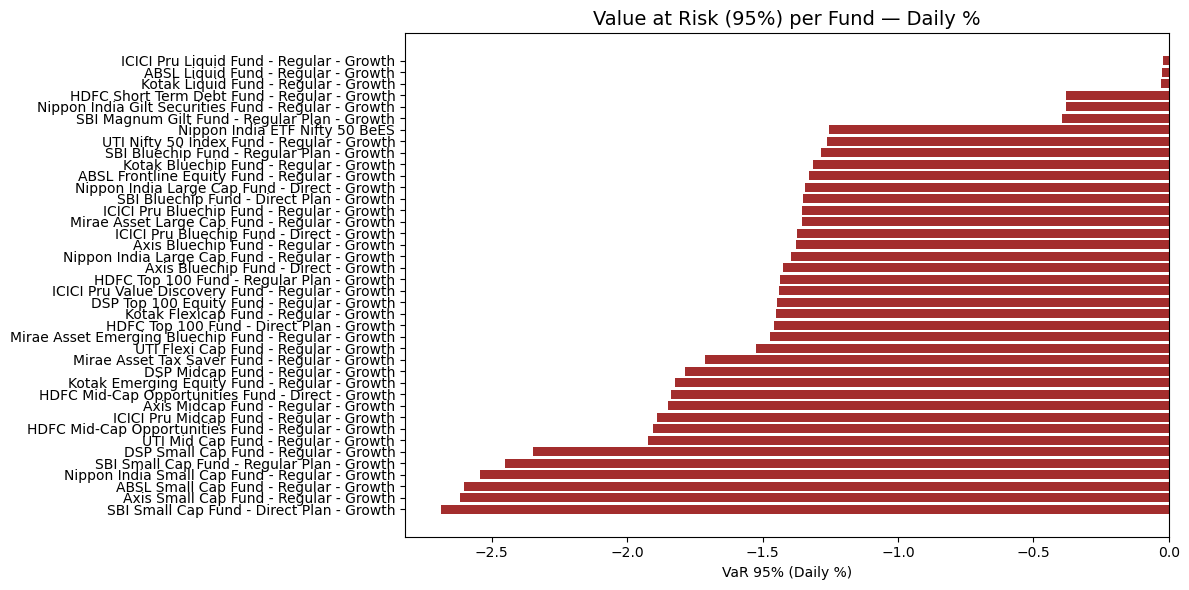

Chart saved!


In [4]:
# ── Chart: VaR per fund ────────────────────────────────────────
plt.figure(figsize=(12, 6))
plt.barh(var_df["scheme_name"], var_df["var_95_pct"], color="#a32d2d")
plt.title("Value at Risk (95%) per Fund — Daily %", fontsize=14)
plt.xlabel("VaR 95% (Daily %)")
plt.tight_layout()
plt.savefig("reports/chart7_var.png")
plt.show()
print("Chart saved!")

In [5]:
transactions["cohort_year"] = (
    transactions
    .groupby("investor_id")["transaction_date"]
    .transform("min")
    .dt.year
)

cohort = (
    transactions
    .groupby("cohort_year")
    .agg(
        num_investors   = ("investor_id",   "nunique"),
        num_transactions= ("investor_id",   "count"),
        avg_amount      = ("amount_inr",    "mean"),
        total_invested  = ("amount_inr",    "sum")
    )
    .reset_index()
)

cohort["avg_amount"]     = cohort["avg_amount"].round(0)
cohort["total_invested"] = (cohort["total_invested"] / 1e7).round(2)

cohort.to_csv(PROC / "cohort_analysis.csv", index=False)
print("Cohort analysis done!")
cohort

Cohort analysis done!


,cohort_year,num_investors,num_transactions,avg_amount,total_invested
0,2024,4803,32499,107423.0,349.11
1,2025,197,279,109159.0,3.05


In [6]:
sip_tx = transactions[transactions["transaction_type"] == "Sip"].copy()
sip_tx = sip_tx.sort_values(["investor_id", "transaction_date"])

sip_tx["prev_date"] = sip_tx.groupby("investor_id")["transaction_date"].shift(1)
sip_tx["gap_days"]  = (sip_tx["transaction_date"] - sip_tx["prev_date"]).dt.days

continuity = (
    sip_tx.groupby("investor_id")
    .agg(
        num_sip = ("transaction_date", "count"),
        avg_gap = ("gap_days", "mean"),
        max_gap = ("gap_days", "max")
    )
    .reset_index()
)

continuity = continuity[continuity["num_sip"] >= 6]
continuity["at_risk"] = continuity["max_gap"] > 35

print(f"SIP continuity done!")
print(f"Total investors with 6+ SIPs : {len(continuity)}")
print(f"At-risk investors            : {continuity['at_risk'].sum()}")
continuity.to_csv(PROC / "sip_continuity.csv", index=False)
continuity.head()

SIP continuity done!
Total investors with 6+ SIPs : 1362
At-risk investors            : 1361


,investor_id,num_sip,avg_gap,max_gap,at_risk
3,INV000004,6,85.400000,265.0,True
7,INV000008,6,70.400000,165.0,True
9,INV000010,6,64.800000,139.0,True
10,INV000011,7,40.166667,125.0,True
11,INV000012,8,57.000000,132.0,True


In [12]:
def recommend_funds(risk_appetite, top_n=3):
    risk_map = {
        "Low"      : ["Low"],
        "Moderate" : ["Low", "Moderate"],
        "High"     : ["Low", "Moderate", "High"],
        "Very High": ["Low", "Moderate", "High", "Very High"]
    }

    eligible = risk_map.get(risk_appetite, ["Moderate"])

    merged = scorecard.merge(
        fund_master[["amfi_code", "risk_category"]],
        on="amfi_code",
        how="left"
    )

    filtered = merged[merged["risk_category"].isin(eligible)]
    top      = filtered.nlargest(top_n, "sharpe_ratio")

    print(f"\nTop {top_n} funds for '{risk_appetite}' risk appetite:")
    print(top[["scheme_name", "risk_category", "sharpe_ratio", "cagr_pct", "score"]].to_string(index=False))

recommend_funds("Low")
recommend_funds("Moderate")
recommend_funds("High")


Top 3 funds for 'Low' risk appetite:
                                 scheme_name risk_category  sharpe_ratio  cagr_pct  score
    ICICI Pru Liquid Fund - Regular - Growth           Low        0.4957      6.97  38.25
        Kotak Liquid Fund - Regular - Growth           Low       -0.0887      6.66  31.88
SBI Magnum Gilt Fund - Regular Plan - Growth           Low       -0.2266      5.67  24.50

Top 3 funds for 'Moderate' risk appetite:
                                   scheme_name risk_category  sharpe_ratio  cagr_pct  score
 Mirae Asset Large Cap Fund - Regular - Growth      Moderate        1.4483     29.71  77.75
     SBI Bluechip Fund - Regular Plan - Growth      Moderate        1.2083     24.77  70.06
Nippon India Large Cap Fund - Regular - Growth      Moderate        1.0817     23.09  70.06

Top 3 funds for 'High' risk appetite:
                                  scheme_name risk_category  sharpe_ratio  cagr_pct  score
Mirae Asset Large Cap Fund - Regular - Growth      Moderate  

In [8]:
print("=" * 55)
print("ADVANCED ANALYTICS FINDINGS")
print("=" * 55)
print(f"1. Highest VaR fund  : {var_df.iloc[0]['scheme_name']}")
print(f"   VaR 95%           : {var_df.iloc[0]['var_95_pct']}%")
print(f"2. Lowest VaR fund   : {var_df.iloc[-1]['scheme_name']}")
print(f"   VaR 95%           : {var_df.iloc[-1]['var_95_pct']}%")
print(f"3. At-risk investors : {continuity['at_risk'].sum()} out of {len(continuity)}")
print(f"4. Cohort years      : {cohort['cohort_year'].tolist()}")
print("=" * 55)

ADVANCED ANALYTICS FINDINGS
1. Highest VaR fund  : SBI Small Cap Fund - Direct Plan - Growth
   VaR 95%           : -2.686%
2. Lowest VaR fund   : ICICI Pru Liquid Fund - Regular - Growth
   VaR 95%           : -0.022%
3. At-risk investors : 1361 out of 1362
4. Cohort years      : [2024, 2025]
